# HomeWork -4
## Objective
 In this homework, you will design a python class that encapsulates common univariate/bivariate analysis tasks. You will practice object oriented programing (OOP) while applying descriptive statistics and visualization to summarize your data and explore the relationship between two variables. 
 
 - Use the example provided in the class activity and expand it. The initializer of the class should take data and print out its shape and column names. 
 - Additionally, your class should include at least 5 methods (function) to do either univariate or bivariate analysis of your choice. 
 - Provide markdowns or comments for each part of your code.  

  - Create an instance of your class using Penguin data and use it to analyze it.
  
  - For each analysis you perform, write 1-2 sentence before that function call that clearly state
    the question you are trying to answer with that analysis. For example: "In this analysis I want to see what is the average mass for each species." 

  


Import Packages and Load Dataset 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
df = sns.load_dataset('penguins')
print(df.shape)
df.head

(344, 7)


<bound method NDFrame.head of     species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen            39.1           18.7              181.0   
1    Adelie  Torgersen            39.5           17.4              186.0   
2    Adelie  Torgersen            40.3           18.0              195.0   
3    Adelie  Torgersen             NaN            NaN                NaN   
4    Adelie  Torgersen            36.7           19.3              193.0   
..      ...        ...             ...            ...                ...   
339  Gentoo     Biscoe             NaN            NaN                NaN   
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
0         3750.0    Male  
1  

My Class Analyzer 

In [11]:
class VariableAnalyzer:
    """ A complete toolkit for Univariate and Bivariate Analysis 
    
    """
    def __init__(self, data):
        self.df = data.copy()
        print(f"loaded {len(data)} rows, {len(data.columns)} columns") 
        print(df.shape)     #this will print out the shape of the data (should match the above line)
        print(df.columns)   #this will print out the column names
        
    # Quantitative vs Quantitative
    def quant_quant(self,x,y):
        """ Bivariate Analysis for two quantitative variables using correlation. Produces a scatter plot. 
        """
        corr = self.df[[x,y]].corr().iloc[0,1].round(3)
        print(corr)
        plt.figure(figsize=(10,6))
        sns.scatterplot(self.df, x = x, y = y  )
        plt.title(f"{x} vs {y} ")
        plt.show()
        return corr
    
    #  Categorical and Quantitative
    def cat_quant(self, cat, quant, hue =None):
        """ Bivariate analysis for one categorical and one quantitative variable using mean. Produces a boxplot. 
        """
        plt.figure(figsize=(10,6))
        sns.boxplot(data = self.df, x = cat, y = quant, hue = hue  )
        plt.title(f"{cat} vs {quant} ")
        plt.xticks(rotation =45)
        plt.show()
        means = self.df.groupby(cat)[quant].mean().round(1)
        print(f"Means by {cat}:")
        print(means)
        return means

    def cat_cat(self, cat1, cat2):
        """Bivariate analysis of two categorical variables. Produces frequency and relative frequency tables. 
        """
        print( "#####Frequencey Table#####\n")
        cont_table2 = pd.crosstab(df[cat1],df[cat2], margins = True)
        print(cont_table2)
        print()
        print( "\n\n#####Relative Frequencey Table#####\n")
        cont_table3 = pd.crosstab(df[cat1],df[cat2], margins = True, normalize = True)
        print(cont_table3)

    def uni_num(self, numvar):
        """Univariate analysis of a numerical variable. Produces a boxplot.
        """
        plt.figure(figsize=(8,4))
        sns.boxplot(x=df[numvar])
        plt.title(f"{numvar} Boxplot")
        plt.show()

    def uni_cat(self,catvar):
        """Univariate analysis of a categorical value using counts. Produces a bar graph. 
        """
        plt.figure(figsize=(10,5))
        df[catvar].value_counts().head(10).plot(kind='bar')
        plt.title(f"Frequency of each {catvar}")
        plt.show()


In [12]:
#Create an instance of the class

analyzer = VariableAnalyzer(df)

loaded 344 rows, 7 columns
(344, 7)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


Scatterplot comparing flipper length and body mass. Are penguins with longer flippers more massive?

loaded 344 rows, 7 columns
(344, 7)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')
0.871


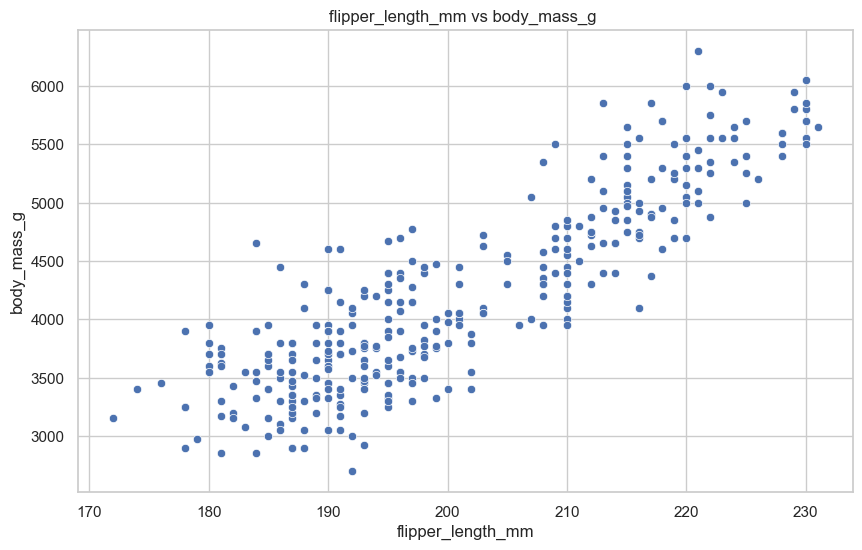

np.float64(0.871)

In [32]:
analyzer.quant_quant('flipper_length_mm','body_mass_g')

Box plots comparing body mass between male and female. Are male or female penguins more massive, independent of species?

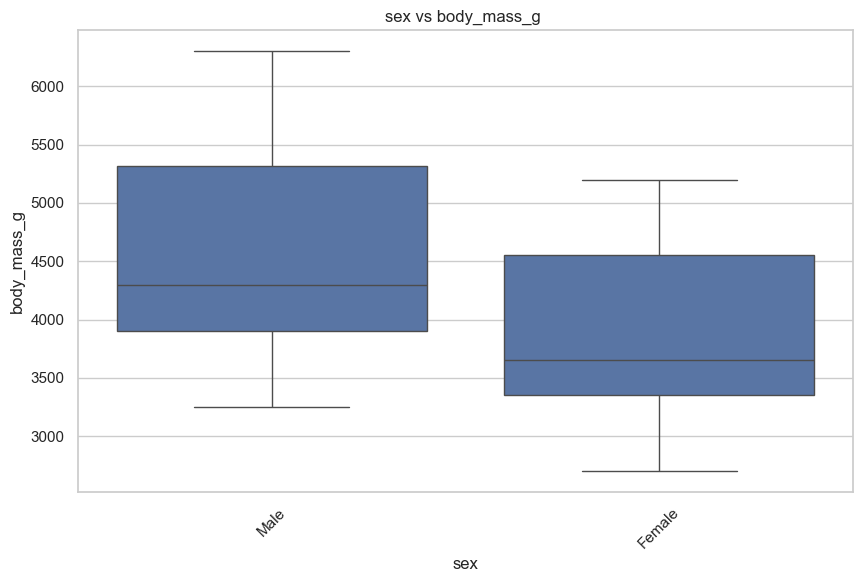

Means by sex:
sex
Female    3862.3
Male      4545.7
Name: body_mass_g, dtype: float64


sex
Female    3862.3
Male      4545.7
Name: body_mass_g, dtype: float64

In [13]:
analyzer.cat_quant('sex','body_mass_g')

Frequency Table of each combination of species and sex. Which species of penguin has a greater percentage of males (or females)?

In [14]:
analyzer.cat_cat('species','sex')

#####Frequencey Table#####

sex        Female  Male  All
species                     
Adelie         73    73  146
Chinstrap      34    34   68
Gentoo         58    61  119
All           165   168  333



#####Relative Frequencey Table#####

sex          Female      Male       All
species                                
Adelie     0.219219  0.219219  0.438438
Chinstrap  0.102102  0.102102  0.204204
Gentoo     0.174174  0.183183  0.357357
All        0.495495  0.504505  1.000000


Box plot of the flipper lengths. How are the flipper lengths distributed across all of the penguins?

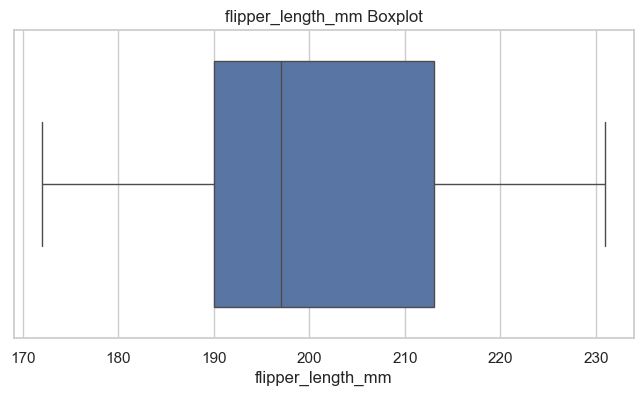

In [15]:
analyzer.uni_num('flipper_length_mm')

Bar graph of the frequency of each species. How do the counts of each penguin species compare?

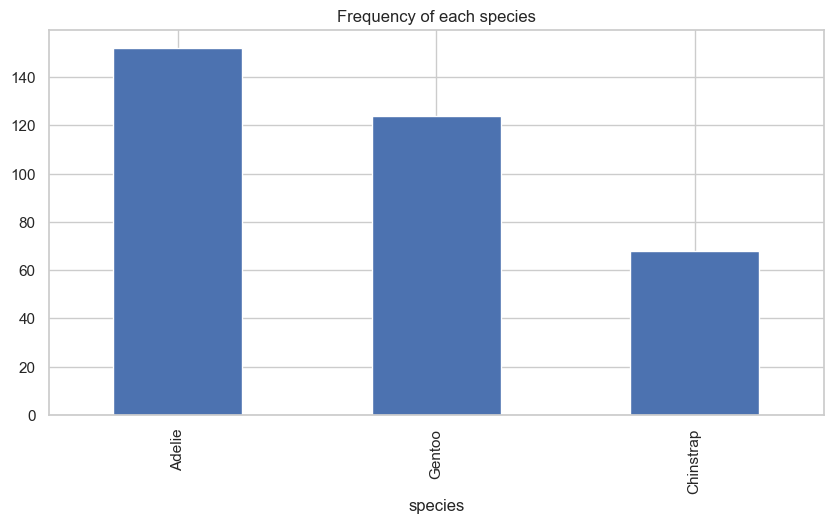

In [16]:
analyzer.uni_cat('species')